# Модуль 5. Линейные модели и метрики

Ноутбук к [модулю 5](https://drobyshevdev.github.io/lemma/modules/05-linear-models-and-metrics/).

Логистическая регрессия собирается из деталей, готовых с модуля 4. Дальше — метрики, и половина ноутбука про то, как они врут.

ROC-AUC, PR-AUC и калибровка считаются здесь руками: библиотечная функция скрывает ровно то, что надо понять.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (9, 3.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

## 1. Логистическая регрессия с нуля

Потеря, градиент и спуск — всё уже выведено в модуле 4. Собираем.

In [2]:
def log_loss(w, X, y, l2=0.0):
    p = np.clip(sigmoid(X @ w), 1e-12, 1 - 1e-12)
    base = -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))
    return float(base + l2 * np.sum(w[:-1] ** 2))     # свободный член не штрафуем

def log_grad(w, X, y, l2=0.0):
    g = X.T @ (sigmoid(X @ w) - y) / len(y)
    penalty = 2 * l2 * w
    penalty[-1] = 0.0
    return g + penalty

def fit_logistic(X, y, l2=0.0, eta=0.5, steps=3000):
    w = np.zeros(X.shape[1])
    for _ in range(steps):
        w -= eta * log_grad(w, X, y, l2)
    return w

def gradient_check(loss, grad, w, *args, h=1e-5):
    analytic = grad(w, *args)
    numeric = np.zeros_like(w)
    for i in range(len(w)):
        step = np.zeros_like(w); step[i] = h
        numeric[i] = (loss(w + step, *args) - loss(w - step, *args)) / (2 * h)
    return float(np.linalg.norm(analytic - numeric) /
                 (np.linalg.norm(analytic) + np.linalg.norm(numeric)))

rng = np.random.default_rng(1)
n = 600
Xr = rng.normal(0, 1, size=(n, 3))
X = np.hstack([Xr, np.ones((n, 1))])
y = (X @ np.array([1.5, -2.0, 0.5, -0.3]) + rng.normal(0, 0.7, n) > 0).astype(float)

print(f"gradient check: {gradient_check(log_loss, log_grad, rng.normal(0,0.3,4), X, y, 0.1):.2e}")
w = fit_logistic(X, y)
print("обученные веса:", w)
print(f"доля положительных: {y.mean():.2f}")

gradient check: 7.16e-12
обученные веса: [ 4.0224 -5.3591  1.3685 -0.8072]
доля положительных: 0.45


## 2. Почему не MSE

Утверждение из текста: у MSE через сигмоиду градиент затухает ровно там, где модель уверенно ошибается.

In [3]:
print(f"{'p (предсказание)':>18} {'градиент MSE':>14} {'градиент log loss':>19}")
for p in [0.5, 0.1, 0.01, 0.001]:
    # объект класса 1: модель предсказывает p, значит ошибается тем сильнее, чем p меньше
    grad_mse = 2 * (p - 1) * p * (1 - p)      # цепное правило через сигмоиду
    grad_log = p - 1                          # то самое сокращение из модуля 4
    print(f"{p:>18} {abs(grad_mse):>14.5f} {abs(grad_log):>19.5f}")

  p (предсказание)   градиент MSE   градиент log loss
               0.5        0.25000             0.50000
               0.1        0.16200             0.90000
              0.01        0.01960             0.99000
             0.001        0.00200             0.99900


Смотрите на столбцы. Чем сильнее ошибка, тем **слабее** сигнал у MSE: при `p = 0.001` градиент почти нулевой, обучение стоит. У log loss наоборот — сигнал максимален.

Это не соглашение и не традиция. MSE душит исправление трудных примеров арифметически.

**Сломайте:** возьмите объект класса 0 и `p` близкое к 1. Симметрично ли поведение?

## 3. Accuracy на несбалансированных данных

Два процента положительных — типичная задача антифрода или редкого дефекта.

In [4]:
def make_imbalanced(rate, n=8000, separation=1.6, seed=0):
    rng = np.random.default_rng(seed)
    y = (rng.random(n) < rate).astype(float)
    x = rng.normal(0, 1, size=(n, 2)) + separation * y[:, None] * np.array([1.0, 0.6])
    return np.hstack([x, np.ones((n, 1))]), y

Xi, yi = make_imbalanced(0.02)
wi = fit_logistic(Xi, yi)
scores = sigmoid(Xi @ wi)

def confusion(y_true, y_pred):
    tp = float(((y_pred == 1) & (y_true == 1)).sum())
    fp = float(((y_pred == 1) & (y_true == 0)).sum())
    fn = float(((y_pred == 0) & (y_true == 1)).sum())
    tn = float(((y_pred == 0) & (y_true == 0)).sum())
    return tp, fp, fn, tn

for name, pred in [("тривиальная база «всё ноль»", np.zeros_like(yi)),
                   ("модель, порог 0.5", (scores > 0.5).astype(float))]:
    tp, fp, fn, tn = confusion(yi, pred)
    acc = (tp + tn) / len(yi)
    print(f"{name:<30} accuracy {acc:.4f}   найдено положительных: {int(tp)} из {int(yi.sum())}")

тривиальная база «всё ноль»    accuracy 0.9808   найдено положительных: 0 из 154
модель, порог 0.5              accuracy 0.9815   найдено положительных: 15 из 154


Обе строки имеют почти одинаковую accuracy. Одна из моделей не нашла вообще ничего.

Вот почему accuracy без доли положительного класса рядом — не число, а украшение отчёта. Это тривиальная база из модуля 1, и проверять её стоит первой.

## 4. Порог как ручка

Модель выдаёт вероятность. Превращать её в ответ — отдельное решение.

In [5]:
def prf(y_true, scores, threshold):
    tp, fp, fn, tn = confusion(y_true, (scores > threshold).astype(float))
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return precision, recall, f1

print(f"{'порог':>7} {'precision':>11} {'recall':>9} {'F1':>7}")
for t in [0.02, 0.05, 0.1, 0.2, 0.5, 0.8]:
    p, r, f = prf(yi, scores, t)
    print(f"{t:>7.2f} {p:>11.3f} {r:>9.3f} {f:>7.3f}")

grid = np.linspace(0.001, 0.999, 400)
curve = np.array([prf(yi, scores, t) for t in grid])
best = grid[curve[:, 2].argmax()]
print(f"\nпорог, максимизирующий F1: {best:.3f}   (не 0.5)")

  порог   precision    recall      F1
   0.02       0.091     0.831   0.164
   0.05       0.156     0.688   0.255
   0.10       0.257     0.558   0.352
   0.20       0.405     0.390   0.397
   0.50       0.625     0.097   0.169
   0.80       0.750     0.019   0.038

порог, максимизирующий F1: 0.214   (не 0.5)


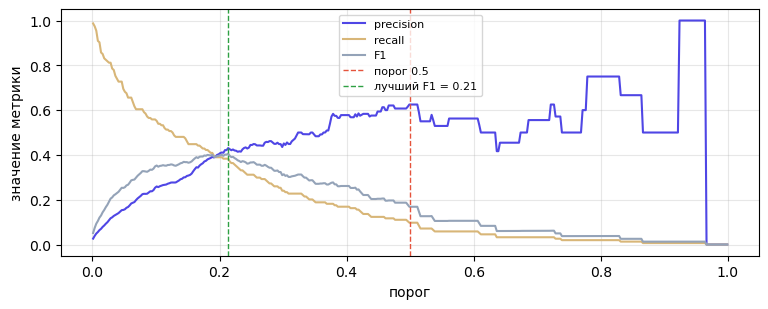

In [6]:
fig, ax = plt.subplots()
ax.plot(grid, curve[:, 0], label="precision", color="#4f46e5")
ax.plot(grid, curve[:, 1], label="recall", color="#d8b678")
ax.plot(grid, curve[:, 2], label="F1", color="#94a3b8")
ax.axvline(0.5, color="#e5533c", ls="--", lw=1, label="порог 0.5")
ax.axvline(best, color="#2ea043", ls="--", lw=1, label=f"лучший F1 = {best:.2f}")
ax.set_xlabel("порог"); ax.set_ylabel("значение метрики")
ax.legend(fontsize=8)
plt.show()

Порог 0.5 стоит далеко от разумного. Сравнение двух моделей при пороге 0.5 сравнивает не модели, а удачность этого порога для каждой.

**Сломайте:** F1 предполагает равную цену ошибок. Посчитайте порог, минимизирующий стоимость, если пропуск стоит 100, а ложная тревога 5.

## 5. ROC-AUC против PR-AUC

Обе площади считаем сами — по определению, трапециями.

  доля положительных   ROC-AUC   PR-AUC


               0.500     0.906    0.906


               0.050     0.912    0.500


               0.005     0.883    0.127


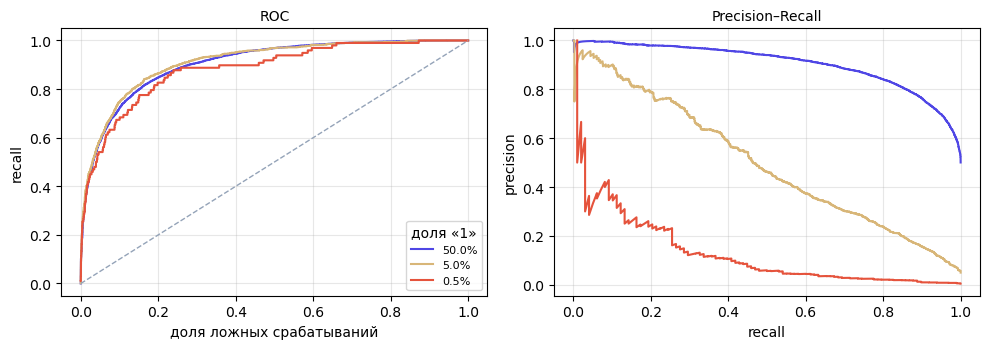

In [7]:
def area_under(x, y):
    """Площадь под кривой методом трапеций.

    Считаем сами, а не np.trapz: эту функцию убрали в NumPy 2, и ноутбук,
    который её зовёт, работает на одной машине и падает на другой.
    """
    return float(np.sum(np.diff(x) * (y[1:] + y[:-1]) / 2))

def roc_pr(y_true, scores):
    """Точки ROC и PR по всем порогам сразу, без библиотек."""
    order = np.argsort(-scores)
    y = y_true[order]
    tp = np.cumsum(y)
    fp = np.cumsum(1 - y)
    total_pos, total_neg = y.sum(), (1 - y).sum()
    recall = tp / total_pos
    fpr = fp / total_neg
    precision = tp / (tp + fp)
    roc_auc = area_under(np.r_[0, fpr], np.r_[0, recall])
    pr_auc = area_under(np.r_[0, recall], np.r_[precision[0], precision])
    return (fpr, recall, precision), float(roc_auc), float(pr_auc)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))
print(f"{'доля положительных':>20} {'ROC-AUC':>9} {'PR-AUC':>8}")
for rate, colour in [(0.5, "#4f46e5"), (0.05, "#d8b678"), (0.005, "#e5533c")]:
    Xa, ya = make_imbalanced(rate, n=20000, seed=4)
    sc = sigmoid(Xa @ fit_logistic(Xa, ya))
    (fpr, rec, prec), roc, pr = roc_pr(ya, sc)
    print(f"{rate:>20.3f} {roc:>9.3f} {pr:>8.3f}")
    ax1.plot(fpr, rec, color=colour, label=f"{rate:.1%}")
    ax2.plot(rec, prec, color=colour, label=f"{rate:.1%}")

ax1.plot([0, 1], [0, 1], ls="--", lw=1, color="#94a3b8")
ax1.set_xlabel("доля ложных срабатываний"); ax1.set_ylabel("recall"); ax1.set_title("ROC", fontsize=10)
ax2.set_xlabel("recall"); ax2.set_ylabel("precision"); ax2.set_title("Precision–Recall", fontsize=10)
ax1.legend(fontsize=8, title="доля «1»")
plt.tight_layout(); plt.show()

Данные одинаково разделимы во всех трёх случаях — меняется только доля положительных. ROC-AUC этого почти не замечает. PR-AUC обрушивается.

Причина в знаменателях. У доли ложных срабатываний знаменатель — все отрицательные, и их огромное количество. У precision знаменатель — только предсказанные положительные, и там ложные видны сразу.

Отсюда правило: доля положительных единицы процентов — смотрите PR-AUC. ROC-AUC 0.95 при доле 0.5 % совместим с precision в несколько процентов.

## 6. Калибровка

Ранжирование и калибровка — разные свойства. Проверим на модели, у которой ранжирование идеальное.

ROC-AUC откалиброванной: 0.8774
ROC-AUC искажённой:      0.8774

Ранжирование не изменилось вообще. Посмотрим на вероятности.


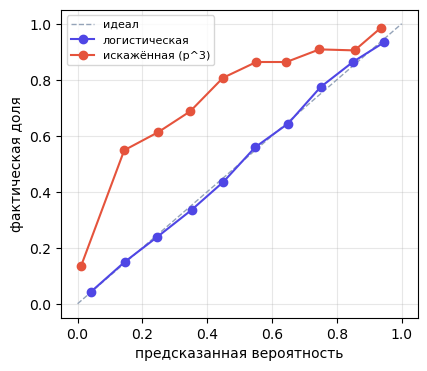

In [8]:
Xc, yc = make_imbalanced(0.3, n=6000, separation=1.4, seed=8)
wc = fit_logistic(Xc, yc)
calibrated = sigmoid(Xc @ wc)

# Монотонное искажение: порядок сохраняется полностью, вероятности врут.
distorted = calibrated ** 3

def reliability(y_true, p, bins=10):
    edges = np.linspace(0, 1, bins + 1)
    idx = np.clip(np.digitize(p, edges) - 1, 0, bins - 1)
    xs, ys = [], []
    for b in range(bins):
        m = idx == b
        if m.sum() > 20:
            xs.append(p[m].mean()); ys.append(y_true[m].mean())
    return np.array(xs), np.array(ys)

_, roc_cal, _ = roc_pr(yc, calibrated)
_, roc_dis, _ = roc_pr(yc, distorted)
print(f"ROC-AUC откалиброванной: {roc_cal:.4f}")
print(f"ROC-AUC искажённой:      {roc_dis:.4f}")
print("\nРанжирование не изменилось вообще. Посмотрим на вероятности.")

fig, ax = plt.subplots(figsize=(4.6, 4))
ax.plot([0, 1], [0, 1], ls="--", lw=1, color="#94a3b8", label="идеал")
for p, name, colour in [(calibrated, "логистическая", "#4f46e5"),
                        (distorted, "искажённая (p^3)", "#e5533c")]:
    xs, ys = reliability(yc, p)
    ax.plot(xs, ys, marker="o", color=colour, label=name)
ax.set_xlabel("предсказанная вероятность"); ax.set_ylabel("фактическая доля")
ax.legend(fontsize=8)
plt.show()

AUC совпадает до четвёртого знака: обе модели упорядочивают объекты одинаково. Но красная линия лежит далеко от диагонали — её «вероятность 0.3» на самом деле означает около 0.6.

Для сортировки лент это неважно. Для расчёта ожидаемой прибыли или порога по цене ошибки — критично.

**Сломайте:** возьмите `distorted = calibrated ** 0.3`. В какую сторону поедет кривая и почему?

## 7. Ridge против коллинеарности

Возвращаемся к примеру из модуля 3, где веса разъезжались в плюс и минус.

In [9]:
rng = np.random.default_rng(11)
a = rng.normal(0, 1, 400)
b = a + rng.normal(0, 0.01, 400)              # почти копия
Xk = np.stack([a, b, np.ones(400)], axis=1)
yk = (3 * a + rng.normal(0, 0.5, 400) > 0).astype(float)

print(f"{'lambda':>8} {'вес a':>9} {'вес b':>9} {'сумма':>9} {'log loss':>10}")
for l2 in [0.0, 1e-4, 1e-2, 1e-1, 1.0]:
    wk = fit_logistic(Xk, yk, l2=l2)
    print(f"{l2:>8} {wk[0]:>9.2f} {wk[1]:>9.2f} {wk[0]+wk[1]:>9.2f} "
          f"{log_loss(wk, Xk, yk):>10.4f}")

  lambda     вес a     вес b     сумма   log loss
     0.0      5.12      5.08     10.20     0.1240
  0.0001      4.80      4.76      9.57     0.1243
    0.01      1.83      1.83      3.66     0.1946


     0.1      0.69      0.69      1.38     0.3624
     1.0      0.15      0.15      0.30     0.5886


Здесь происходит не то, что было в модуле 3, и разница поучительна.

Там точный решатель разносил веса коллинеарных признаков в плюс и минус. Здесь без всякого штрафа веса вышли почти равными: 5.12 и 5.08. **Спуск из нуля сам себя регуляризует** — двигаясь маленькими шагами от начала координат, он приходит к решению с наименьшей нормой, а оно делит вес между близнецами поровну.

Это называется неявной регуляризацией, и запомнить её стоит: **выбор оптимизатора влияет на то, какое из множества решений вы получите**. Формула решения одна, ответы разные.

Что делает явный штраф: с ростом `lambda` оба веса вместе едут к нулю, сохраняя равенство. Сумма — а именно она определяет предсказание — сжимается вместе с ними, и log loss начинает портиться. Это и есть цена регуляризации, которую подбирают на валидации.

**Сломайте:** решите ту же задачу через `np.linalg.lstsq` вместо спуска и сравните веса. Разойдутся ли они теперь?


## Итог

1. Логистическая регрессия собирается из модуля 4 целиком: потеря, градиент, спуск, проверка.
2. У MSE градиент затухает там, где модель уверенно ошибается. У log loss — нет.
3. Модель, не нашедшая ни одного положительного объекта, имеет ту же accuracy, что и рабочая.
4. Порог 0.5 почти никогда не оптимален и является вашим решением, а не свойством модели.
5. При доле положительных 0.5 % ROC-AUC почти не двигается, PR-AUC обрушивается.
6. Две модели с одинаковым до четвёртого знака AUC могут выдавать совершенно разные вероятности.
7. L2 сближает разъехавшиеся веса, почти не портя потерю.

Дальше — [модуль 6](https://drobyshevdev.github.io/lemma/modules/06-trees-and-ensembles/): деревья и бустинг, главная базовая линия курса.